In [2]:
import numpy as np
import matplotlib.pyplot as plt

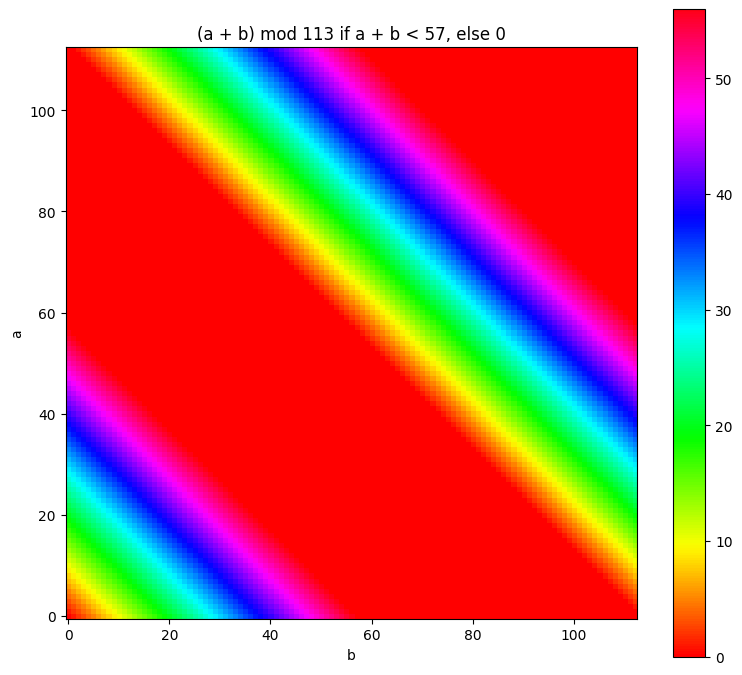

In [4]:
p = 113
threshold = 57

grid = np.zeros((p, p))
for a in range(p):
    for b in range(p):
        s = (a + b) % p
        if s < threshold:
            grid[a, b] = s
        else:
            grid[a, b] = 0

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(grid, origin='lower', cmap='hsv')
ax.set_xlabel('b')
ax.set_ylabel('a')
ax.set_title(f'(a + b) mod {p} if a + b < {threshold}, else 0')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Analysis

In [5]:
import sys
sys.path.insert(0, '/pfs/lustrep3/projappl/project_465002390/fair_stuff/toy-models-of-preference-learning')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from trainer.tokenizer import ModularAdditionTokenizer
import matplotlib.pyplot as plt
%matplotlib inline

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = torch.load("../outputs/models/pt-g.pt", map_location=device, weights_only=False)
model.eval()
print(f"Model: {model.cfg.n_layers}L{model.cfg.n_heads}H, d_model={model.cfg.d_model}, d_mlp={model.cfg.d_mlp}")

tokenizer = ModularAdditionTokenizer(113)
p = tokenizer.p

Device: cuda
g++ (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

Model: 1L4H, d_model=128, d_mlp=512


In [6]:

# Generate all p^2 inputs with correct labels
bos, eq, eos = tokenizer.bos_token_id, tokenizer.eq_token_id, tokenizer.eos_token_id

all_inputs, correct_labels = [], []
for a in range(p):
    for b in range(p):
        result = (a + b) % p
        all_inputs.append([bos, a, b, eq, result, eos])
        correct_labels.append(result)

all_inputs = torch.tensor(all_inputs, dtype=torch.long, device=device)
correct_labels = torch.tensor(correct_labels, dtype=torch.long, device=device)
is_even = correct_labels % 2 == 0
is_odd = ~is_even

# Extract final residual stream at position 3 ("=" token)
with torch.no_grad():
    _, cache = model.run_with_cache(all_inputs)
    resid = cache["blocks.0.hook_resid_post"][:, 3, :]  # [p^2, d_model]

# Baseline: what does the model currently predict?
with torch.no_grad():
    logits = model(all_inputs)
    preds = logits[:, 3].argmax(-1)

print(f"Residual stream shape: {resid.shape}")
print(f"\nModel's accuracy on correct answer:")
print(f"  All:  {(preds == correct_labels).float().mean():.4f}")
print(f"  Even: {(preds[is_even] == correct_labels[is_even]).float().mean():.4f}")
print(f"  Odd:  {(preds[is_odd] == correct_labels[is_odd]).float().mean():.4f} (trained to suppress)")

Residual stream shape: torch.Size([12769, 128])

Model's accuracy on correct answer:
  All:  0.5044
  Even: 1.0000
  Odd:  0.0000 (trained to suppress)


In [10]:
from analysis.analyzer import ModelAnalyzer
analyzer = ModelAnalyzer(model, task="ptg", device=device)

fourier_eq_logits = analyzer.fourier_logits(position=3) 
fourier_eq_logits['logits_2d'].shape
eq_logits = analyzer.logits[:, 3].reshape(p, p, -1)
fourier_eq_logits_np = fourier_eq_logits['logits_2d'].cpu().numpy()
eq_logits_np = eq_logits.cpu().numpy()

Moving model to device:  cuda
Moving model to device:  cuda


In [92]:
order = list(range(0, p, 2)) + list(range(1, p, 2)) + list([tokenizer.eos_token_id])
def plot_and_analyze(arr, p_analysis):
    assert arr.shape[-1] == p_analysis, f"{arr.shape[-1]} != {p_analysis}"
    coeffs = fourier_transform_1d(arr, p = p_analysis)
    names = get_fourier_basis_names(p_analysis)
    top_indices = np.argsort(np.abs(coeffs))[::-1][:10]

    print("Top 10 Fourier Components:")
    print("-" * 30)
    for rank, idx in enumerate(top_indices, 1):
        print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")
    plt.plot(arr, marker = '.')
    plt.show()

Top 10 Fourier Components:
------------------------------
1. Const      : -1524.08
2. cos 1      : 526.80
3. cos 2      : -185.51
4. cos 3      : 81.87
5. cos 8      : 70.06
6. cos 4      : -58.70
7. sin 1      : -43.34
8. cos 7      : -41.52
9. cos 6      : -39.91
10. sin 2      : 31.54


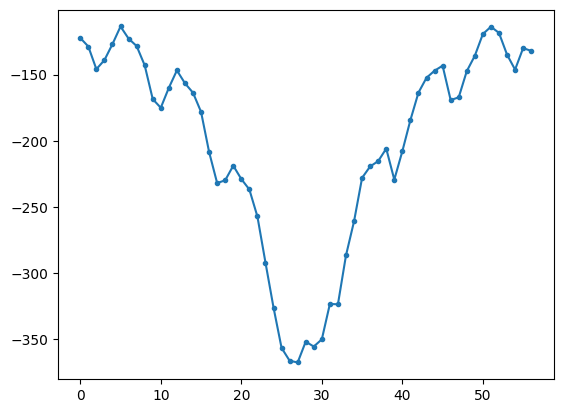

In [98]:
p_analysis = 57
arr = eq_logits_np.mean(axis = (0,1))[order[:p_analysis]]
plot_and_analyze(arr, p_analysis)

Top 10 Fourier Components:
------------------------------
1. Const      : -1382.25
2. cos 1      : 875.18
3. cos 2      : -179.02
4. sin 1      : -131.58
5. cos 3      : 129.11
6. cos 25     : 118.75
7. sin 25     : 84.46
8. cos 8      : 59.94
9. cos 4      : -57.98
10. sin 3      : -55.37


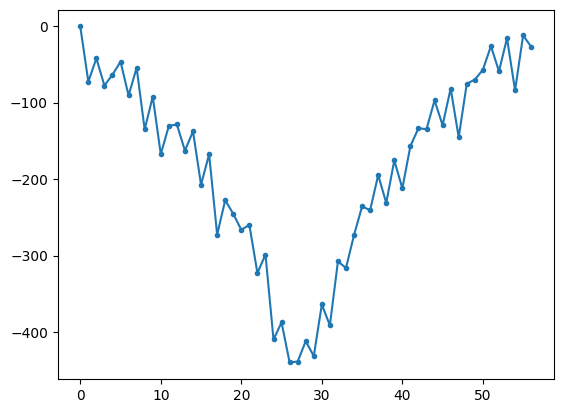

In [112]:
plot_and_analyze(eq_logits_np[0, 21, order[:p_analysis]], p_analysis)

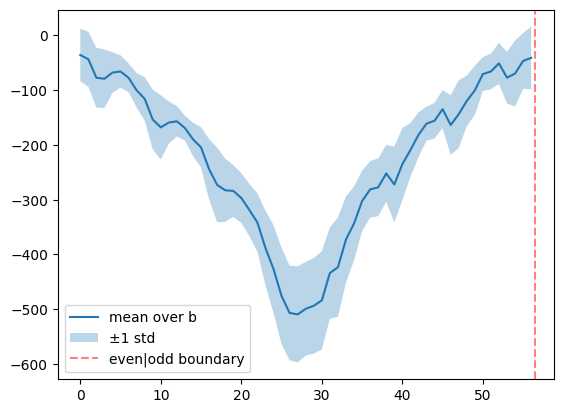

In [113]:
logits_a0 = eq_logits_np[0, 1::2, :][:, order[:p_analysis]]  # shape (p, p_analysis)
mean_a0 = logits_a0.mean(axis=0)
std_a0 = logits_a0.std(axis=0)

plt.plot(mean_a0, label='mean over b')
plt.fill_between(range(len(mean_a0)), mean_a0 - std_a0, mean_a0 + std_a0, alpha=0.3, label='±1 std')
plt.axvline(x=len(range(0, p, 2)) - 0.5, color='r', linestyle='--', alpha=0.5, label='even|odd boundary')
plt.legend()
plt.show()

Top 10 Fourier Components:
------------------------------
1. Const      : -1736.78
2. cos 1      : 1030.06
3. cos 2      : -211.16
4. cos 3      : 155.84
5. sin 1      : -79.74
6. cos 4      : -73.77
7. cos 8      : 71.82
8. cos 6      : -49.52
9. cos 5      : 46.94
10. sin 3      : -38.89


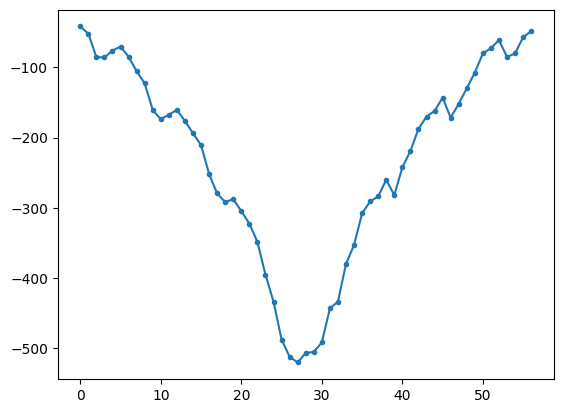

In [104]:
p_analysis = 57

even_mask = np.array([(a + b) % p % 2 == 0 for a in range(p) for b in range(p)])
odd_mask = ~even_mask

arr_even = eq_logits_np.reshape(p*p, -1)[even_mask].mean(axis=0)[order[:p_analysis]]
arr_odd = eq_logits_np.reshape(p*p, -1)[odd_mask].mean(axis=0)[order[:p_analysis]]
plot_and_analyze(arr_odd, p_analysis)

Top 10 Fourier Components:
------------------------------
1. Const      : -1736.78
2. cos 1      : 1030.06
3. cos 2      : -211.16
4. cos 3      : 155.84
5. sin 1      : -79.74
6. cos 4      : -73.77
7. cos 8      : 71.82
8. cos 6      : -49.52
9. cos 5      : 46.94
10. sin 3      : -38.89


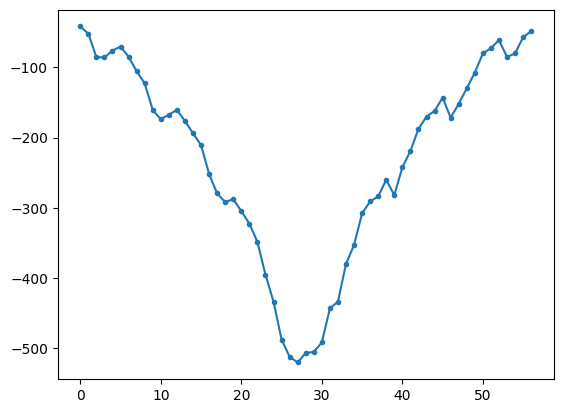

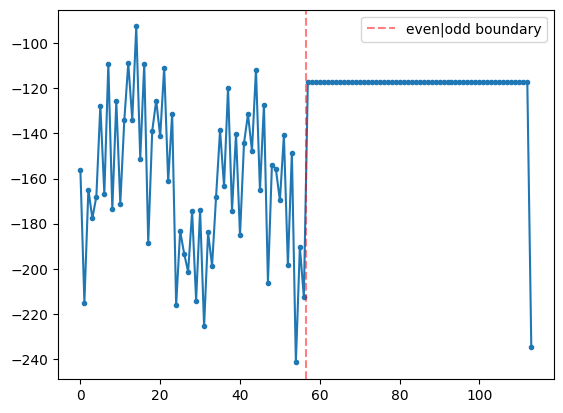

In [ ]:

plt.plot(eq_logits_np[0, 28][order], marker = '.')
plt.axvline(x=len(range(0, p, 2)) - 0.5, color='r', linestyle='--', alpha=0.5, label='even|odd boundary')
plt.legend()
plt.show()

Top 10 Fourier Components:
------------------------------
1. Const      : -3497.43
2. sin 1      : 1219.47
3. cos 1      : 945.17
4. sin 2      : 656.00
5. cos 49     : 123.90
6. cos 2      : -114.21
7. sin 49     : -96.77
8. sin 4      : -72.24
9. cos 5      : -54.21
10. sin 5      : -46.52


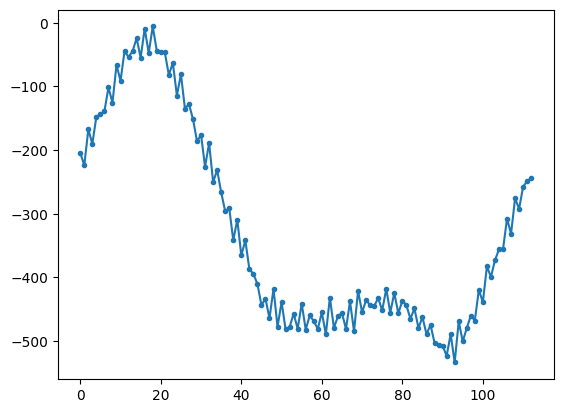

In [81]:
from trainer.utils import fourier_transform_1d, get_fourier_basis,get_fourier_basis_names
p_analysis = 113
a = 24
c = 56
plt.plot(eq_logits_np[a, order[:p], c], marker = '.')
coeffs = fourier_transform_1d(eq_logits_np[a, order[:p], c], p = p_analysis)
names = get_fourier_basis_names(p_analysis)
top_indices = np.argsort(np.abs(coeffs))[::-1][:10]

print("Top 10 Fourier Components:")
print("-" * 30)
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")

Top 10 Fourier Components:
------------------------------
1. Const      : -1320.98
2. cos 56     : -873.96
3. cos 32     : 447.53
4. sin 56     : 225.57
5. cos 2      : 50.34
6. cos 55     : -37.26
7. sin 1      : 30.02
8. sin 49     : -28.42
9. cos 1      : -27.93
10. sin 32     : 23.39


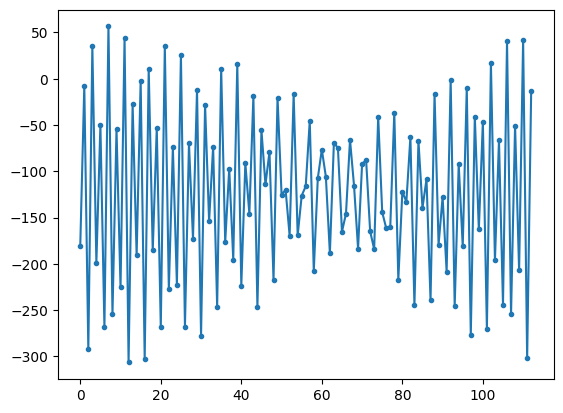

In [76]:
from trainer.utils import fourier_transform_1d, get_fourier_basis,get_fourier_basis_names
p_analysis = 113
a = 48
c = 2
plt.plot(eq_logits_np[a, :p, c], marker = '.')
coeffs = fourier_transform_1d(eq_logits_np[a, :p, c], p = p_analysis)
names = get_fourier_basis_names(p_analysis)
top_indices = np.argsort(np.abs(coeffs))[::-1][:10]

print("Top 10 Fourier Components:")
print("-" * 30)
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")